In [2]:
import pandas as pd

sales = pd.read_csv("data/sales_train_evaluation.csv")
calendar = pd.read_csv("data/calendar.csv")
prices = pd.read_csv("data/sell_prices.csv")

print("sales:", sales.shape)
print("calendar:", calendar.shape)
print("prices:", prices.shape)
sales.head()

sales: (30490, 1947)
calendar: (1969, 14)
prices: (6841121, 4)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


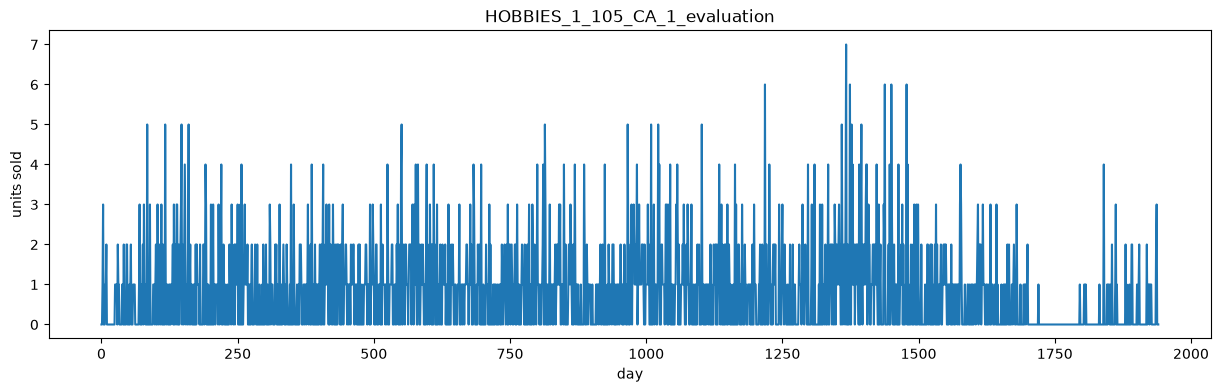

In [3]:
import matplotlib.pyplot as plt

row = sales.iloc[100]                     # pick row 100, arbitrary product
daily = row[[c for c in sales.columns if c.startswith("d_")]].astype(int)

plt.figure(figsize=(15, 4))
plt.plot(daily.values)
plt.title(row["id"])
plt.xlabel("day"); plt.ylabel("units sold")
plt.show()

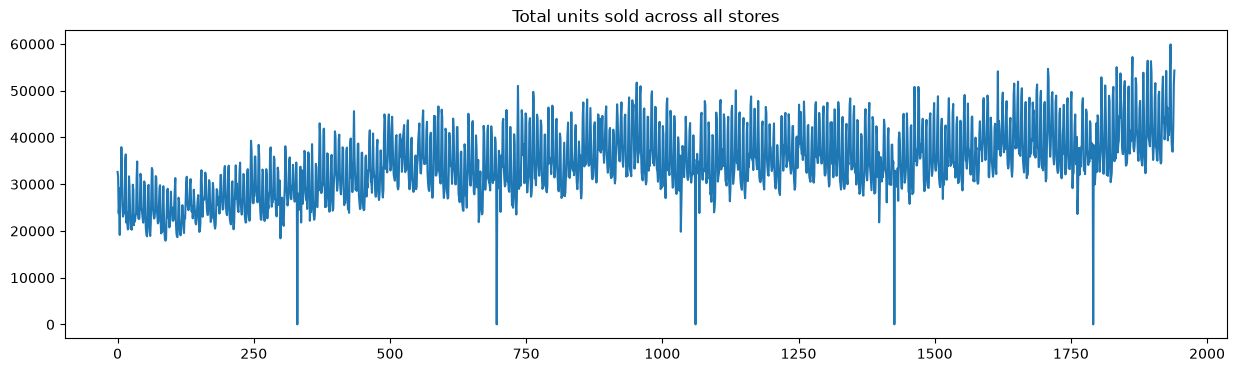

In [4]:
day_cols = [c for c in sales.columns if c.startswith("d_")]
total = sales[day_cols].sum()

plt.figure(figsize=(15, 4))
plt.plot(total.values)
plt.title("Total units sold across all stores")
plt.show()

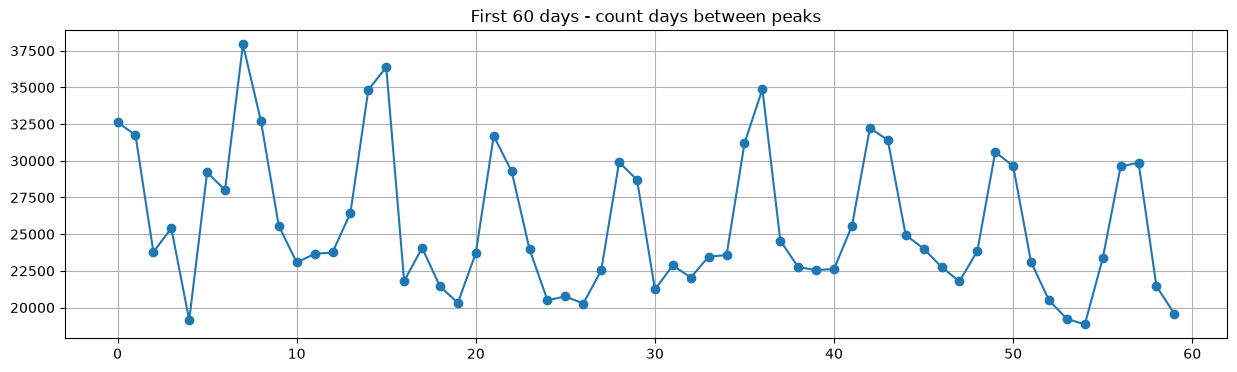

In [5]:
plt.figure(figsize=(15, 4))
plt.plot(total.values[0:60], marker="o")
plt.title("First 60 days - count days between peaks")
plt.grid(True)
plt.show()

In [6]:
zero_pct = (sales[day_cols] == 0).values.mean()
print(f"Percent of all product-days with ZERO sales: {zero_pct:.1%}")

Percent of all product-days with ZERO sales: 68.0%


In [7]:
calendar.head(10)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0
